In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr

In [2]:
def find_best_threshold(scores, y_test):
    thresholds = np.linspace(0.05, 0.95, 100)
    best_threshold = 0
    best_accuracy  = 0

    for t in thresholds:
        y_pred = (scores > t).astype(int)
        accuracy  = accuracy_score(y_test, y_pred)
        if accuracy  > best_accuracy :
            best_accuracy  = accuracy 
            best_threshold = t

    print(f"Najlepszy próg: {best_threshold:.2f}, Accuracy : {best_accuracy :.4f}")
    return best_threshold

In [3]:
label_column_name = "label"
database_name = "bdp"
features_table_name = "scaled_features"
benchmark_data_bucket_path = "s3://bdp-test-data/scaled/part-00000-e3ab15b7-a921-4972-af6c-78d73ca30408-c000.zstd.parquet"
athena_results_bucket_path = "s3://bdp-athena-results/"
models_bucket_path = "s3://bdp-models/gan/"

In [4]:
selected_features = [ "block_timestamp",  "transaction_index",  "fee",  "total_transferred_value",  "sent_value",
  "received_value",  "network_name",  "avg_sent_value",  "avg_received_value",  "sum_sent_value",  "sum_received_value",
  "sum_total_value_for_sender",  "sum_total_value_for_receiver",  "min_sent_value",  "min_received_value",  "min_total_value_for_receiver",
  "mode_received_value",  "stddev_sent_value",  "stddev_received_value",  "stddev_total_value_for_receiver",  "num_sent_transactions",
  "num_received_transactions",  "avg_time_between_sent_transactions",  "avg_time_between_received_transactions",  "avg_outgoing_speed_count",
  "avg_incoming_speed_count",  "avg_outgoing_speed_value",  "avg_incoming_speed_value",  "avg_outgoing_acceleration_count",
  "avg_incoming_acceleration_count",  "avg_outgoing_acceleration_value",  "avg_incoming_acceleration_value",  "avg_fee_paid",
  "total_fee_paid",  "activity_duration_for_sender",  "first_transaction_timestamp_for_sender",  "last_transaction_timestamp_for_sender",
  "activity_duration_for_receiver",  "first_transaction_timestamp_for_receiver",  "last_transaction_timestamp_for_receiver",  "unique_out_degree",  "unique_in_degree"
]

In [5]:
latent_dim = 64 
input_dim = len(selected_features)
hidden_dim = 256
batch_size = 64 
num_epochs = 10 
lr = 1e-5       
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
columns_str = ", ".join(selected_features)

sql_query = f"""
SELECT {columns_str}
FROM {database_name}.{features_table_name}
LIMIT 1000000
"""

features_data = wr.athena.read_sql_query(
    database=database_name,
    sql=sql_query,
    s3_output=athena_results_bucket_path,
    ctas_approach=True
)
X_train = features_data.values.astype(np.float32)

benchmark = wr.s3.read_parquet(
    path=f"{benchmark_data_bucket_path}"
)

X_test = benchmark[selected_features].values.astype(np.float32)
y_test = benchmark[label_column_name].map({True: 1, False: 0}).values

In [8]:
train_dataset = TensorDataset(torch.tensor(X_train))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [9]:
class Generator(nn.Module):
    def __init__(self, latent_dim, input_dim, hidden_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
        )
    def forward(self, z):
        return self.net(z)

In [10]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )


    def forward(self, x):
        return self.net(x)

In [11]:
generator = Generator(latent_dim, input_dim, hidden_dim).to(device)
discriminator = Discriminator(input_dim, hidden_dim).to(device)

optim_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999)) 
optim_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

criterion = nn.BCELoss()

In [12]:
for epoch in range(num_epochs):
    for real_samples, in train_loader:
        real_samples = real_samples.to(device)
        batch_size_current = real_samples.size(0)

        real_labels = torch.ones(batch_size_current, 1).to(device)
        fake_labels = torch.zeros(batch_size_current, 1).to(device)

        outputs_real = discriminator(real_samples)
        d_loss_real = criterion(outputs_real, real_labels)

        z = torch.randn(batch_size_current, latent_dim).to(device)
        fake_samples = generator(z)
        outputs_fake = discriminator(fake_samples.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        optim_D.zero_grad()
        d_loss.backward()
        optim_D.step()

        z = torch.randn(batch_size_current, latent_dim).to(device)
        fake_samples = generator(z)
        outputs_fake_for_G = discriminator(fake_samples)
        g_loss = criterion(outputs_fake_for_G, real_labels)

        optim_G.zero_grad()
        g_loss.backward()
        optim_G.step()

    print(f"Epoka [{epoch+1}/{num_epochs}] | d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}")

torch.save(generator.state_dict(), "generator2.pth")
torch.save(discriminator.state_dict(), "discriminator2.pth")

Epoka [1/10] | d_loss: 90.0842, g_loss: 0.6873
Epoka [2/10] | d_loss: 76.9675, g_loss: 0.6806
Epoka [3/10] | d_loss: 72.4700, g_loss: 0.6810
Epoka [4/10] | d_loss: 70.7321, g_loss: 0.6823
Epoka [5/10] | d_loss: 81.0420, g_loss: 0.6894
Epoka [6/10] | d_loss: 69.2155, g_loss: 0.6881
Epoka [7/10] | d_loss: 67.3843, g_loss: 0.6791
Epoka [8/10] | d_loss: 43.3811, g_loss: 0.6885
Epoka [9/10] | d_loss: 68.5922, g_loss: 0.6834
Epoka [10/10] | d_loss: 53.4430, g_loss: 0.6833


In [16]:
discriminator.eval()
    
with torch.no_grad():
    scores = discriminator(torch.tensor(X_test, dtype=torch.float32, device=device)).cpu().numpy().ravel()
np.savetxt("data2.csv", scores, delimiter=",", fmt="%d")

threshold = 0.8
outlier_predictions = (scores > threshold).astype(int)

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92     50702
           1       0.76      0.61      0.68     14034

    accuracy                           0.87     64736
   macro avg       0.83      0.78      0.80     64736
weighted avg       0.87      0.87      0.87     64736



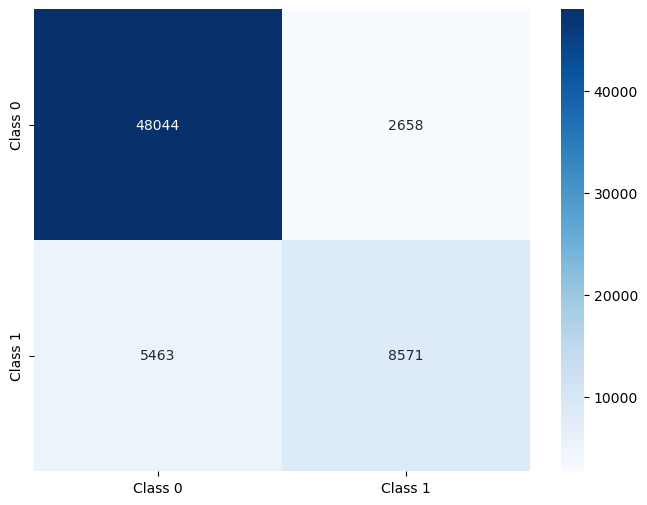

In [17]:
cm = confusion_matrix(y_test, outlier_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])

print("Classification Report:\n", classification_report(y_test, outlier_predictions))